# 📓 Découverte des Notebooks Jupyter
### Ce qu'ils sont et comment ils fonctionnent

---

**Bienvenue !** Ce notebook est lui-même l'exemple. En le lisant et en exécutant ses cellules, vous allez comprendre le fonctionnement des notebooks de l'intérieur.

> 💡 **Comment naviguer** : utilisez `Shift + Entrée` pour exécuter une cellule et passer à la suivante. Essayez sur toutes les cellules de code que vous croiserez !

## 1. Qu'est-ce qu'un notebook ?

Un notebook Jupyter est un **document interactif** qui mélange trois choses dans un seul fichier :

- 📝 Du **texte formaté** (titres, paragraphes, équations, images)
- 💻 Du **code exécutable** (Python, R, SQL...)
- 📊 Les **résultats de l'exécution** (tableaux, graphiques, sorties texte)

| Contexte | Avantage |
|----------|----------|
| Exploration de données | On voit le résultat immédiatement, on itère |
| Enseignement | On peut expliquer ET montrer en même temps |
| Rapport d'analyse | Le code et les conclusions vivent au même endroit |
| Prototypage ML | On teste des idées rapidement, cellule par cellule |

**Le fichier sous-jacent** est un simple JSON avec l'extension `.ipynb` (IPython Notebook). Tout y est stocké : le texte, le code, ET les résultats des exécutions précédentes.

## 2. Anatomie d'un notebook : les cellules

Un notebook est une **séquence de cellules**. Il en existe trois types principaux.

### Type 1: Cellule Markdown (comme celle-ci)

La cellule que vous lisez en ce moment EST une cellule Markdown. Elle contient du texte enrichi :

- **Gras** avec `**texte**`
- *Italique* avec `*texte*`
- `Code inline` avec des backticks
- Des titres avec `#`, `##`, `###`...
- Des listes, tableaux, liens, images, équations LaTeX...

Quand vous "exécutez" une cellule Markdown, Jupyter la **rend** visuellement : le balisage devient mise en forme.

> Double-cliquez sur cette cellule pour voir le Markdown brut, puis `CTRL + Entrée` pour la re-rendre.

---

### Type 2: Cellule de code

Elle contient du code Python (ou autre). Quand vous l'exécutez, le résultat s'affiche juste en dessous.

---

### Type 3: Cellule Raw

Rarement utilisée. Le contenu n'est ni rendu ni exécuté. Utile pour du contenu destiné à un convertisseur externe (nbconvert).

## 3. Votre première cellule de code

La cellule suivante est une cellule de code. Remarquez :
- Son fond légèrement différent
- Le `[ ]` à gauche (il affichera le numéro d'exécution après le run)
- Le bouton ▶ dans la barre d'outils

Exécutez-la avec `Shift + Entrée` :

In [9]:
print("Bonjour depuis une cellule de code Python !")
print("Ce texte s'affiche juste en dessous de la cellule.")

# La dernière expression d'une cellule est affichée automatiquement
2 + 2

Bonjour depuis une cellule de code Python !
Ce texte s'affiche juste en dessous de la cellule.


4

**Ce qui vient de se passer :**
- `print()` produit une **sortie standard**
- `2 + 2` est la dernière expression : Jupyter l'affiche automatiquement comme **Out[n]**
- Le numéro entre crochets `[1]` indique l'ordre d'exécution dans la session

> 🔍 Ce numéro est important. On y revient en section 5.

## 4. Le Kernel : le moteur derrière le notebook

### Qu'est-ce que le kernel ?

Le kernel est un **processus séparé** qui tourne en arrière-plan. C'est lui qui exécute réellement votre code.

```
┌─────────────────────────────────────┐
│           Votre navigateur           │
│   ┌─────────────────────────────┐   │
│   │       Interface Jupyter      │   │
│   │  (affichage, édition, UI)   │   │
│   └──────────────┬──────────────┘   │
│                  │ ZeroMQ (sockets)  │
│   ┌──────────────▼──────────────┐   │
│   │         Kernel Python        │   │
│   │  (interpréteur Python réel) │   │
│   └─────────────────────────────┘   │
└─────────────────────────────────────┘
```

La communication se fait via des **sockets ZeroMQ** : le navigateur envoie le code, le kernel l'exécute et renvoie les résultats.

### États du kernel

| Icône / Indicateur | Signification |
|---|---|
| ⚪ Cercle vide | Kernel prêt (idle) |
| ⚫ Cercle plein | Kernel en train d'exécuter |
| 💀 Skull / Dead | Kernel mort, il faut le relancer |

### Actions disponibles sur le kernel

- **Interrupt** (`I, I`) : stoppe une exécution en cours (équivalent de `Ctrl+C`)
- **Restart** : redémarre le kernel **toutes les variables sont perdues**
- **Restart & Run All** : repart de zéro et réexécute tout le notebook dans l'ordre

## 5. L'état partagé entre cellules

C'est **la chose la plus importante à comprendre** pour éviter des bugs.

Toutes les cellules d'un notebook **partagent le même espace de noms** (namespace). Une variable définie dans une cellule est accessible dans toutes les autres.

Exécutez les trois cellules suivantes dans l'ordre :

In [10]:
# Cellule A — on définit une variable
prenom = "Alice"
score = 42
print(f"Variable 'prenom' créée : {prenom}")

Variable 'prenom' créée : Alice


In [11]:
# Cellule B — on utilise la variable définie dans A
# (même si cette cellule est physiquement séparée)
message = f"{prenom} a obtenu {score} points."
print(message)

Alice a obtenu 42 points.


In [12]:
# Cellule C — inspecter l'état actuel du kernel
# %whos est une "magic command" qui liste toutes les variables actives
%whos

Variable   Type    Data/Info
----------------------------
message    str     Alice a obtenu 42 points.
prenom     str     Alice
score      int     42


### ⚠️ Le piège de l'ordre d'exécution

Le numéro `[n]` à gauche de chaque cellule indique **quand** elle a été exécutée, pas sa position dans le notebook. C'est ce qui peut provoquer des bugs difficiles à déboguer.

**Scénario classique du bug :**

1. Vous exécutez les cellules de haut en bas (normal)
2. Vous remontez modifier une cellule du milieu et la réexécutez
3. Les cellules du bas utilisent l'**ancienne** valeur, PAS la nouvelle... sauf si vous les réexécutez aussi

La règle d'or : **un notebook sain peut être réexécuté de haut en bas sans erreur.**

Pour vérifier : `Kernel → Restart & Run All`

## 6. Les Magic Commands

Les magic commands sont des raccourcis spéciaux préfixés par `%` (ligne) ou `%%` (cellule entière). Elles ne font pas partie de Python standard — c'est IPython qui les fournit.

In [13]:
# %time : mesure le temps d'exécution d'une ligne
%time sum(range(1_000_000))

CPU times: user 23.8 ms, sys: 27 μs, total: 23.8 ms
Wall time: 23.6 ms


499999500000

In [14]:
# %timeit : répète plusieurs fois pour une mesure fiable
%timeit sum(range(10_000))

135 μs ± 5.44 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [15]:
# %%time : mesure la cellule entière (double %)
%%time

total = 0
for i in range(500_000):
    total += i
print(f"Total = {total}")

UsageError: Line magic function `%%time` not found.


In [16]:
# Autres magic commands utiles — décommentez et testez !

# %pwd          → répertoire courant
# %ls           → liste les fichiers
# %history      → historique des commandes exécutées
# %matplotlib inline  → affiche les graphiques dans le notebook
# %load_ext autoreload → recharge automatiquement les modules modifiés
# !commande     → exécute une commande shell (ex: !pip install pandas)

# Lister toutes les magic commands disponibles :
%lsmagic

'Available line magics:\n%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cat  %cd  %clear  %code_wrap  %colors  %conda  %config  %connect_info  %cp  %debug  %dhist  %dirs  %doctest_mode  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %lf  %lk  %ll  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %lx  %macro  %magic  %mamba  %man  %matplotlib  %micromamba  %mkdir  %more  %mv  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %rep  %rerun  %reset  %reset_selective  %rm  %rmdir  %run  %save  %sc  %set_env  %store  %subshell  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode\n\nAvailable cell magics:\n%%!  %%HTML  %%SVG  %%bash  %%capture  %%code_wrap  %%debug  %%file  %%html  

## 7. Afficher des données : au-delà du print()

Un des grands avantages des notebooks : les objets Python savent **s'afficher eux-mêmes** de façon riche. Pandas, matplotlib, PIL... chacun a son rendu natif.

In [17]:
import pandas as pd

# Un DataFrame s'affiche comme un tableau HTML formaté
data = {
    "Produit": ["Café", "Thé", "Jus d'orange", "Eau"],
    "Prix (€)": [1.50, 1.20, 2.00, 0.80],
    "Calories": [5, 2, 110, 0],
}
df = pd.DataFrame(data)
df  # Pas de print() — Jupyter détecte le DataFrame et le rend en HTML

,Produit,Prix (€),Calories
0,Café,1.5,5
1,Thé,1.2,2
2,Jus d'orange,2.0,110
3,Eau,0.8,0


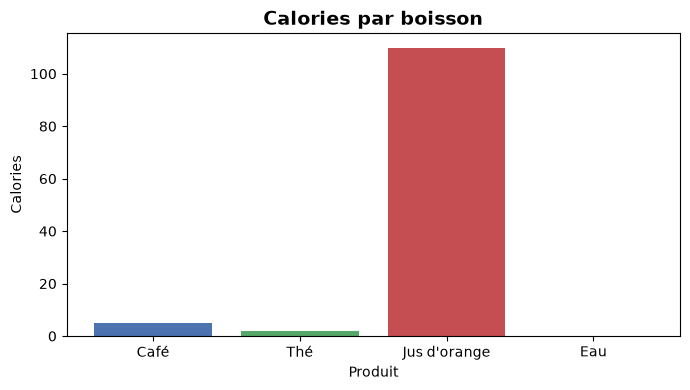

In [18]:
import matplotlib.pyplot as plt

# Un graphique matplotlib s'affiche inline dans le notebook
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(df["Produit"], df["Calories"], color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
ax.set_title("Calories par boisson", fontsize=14, fontweight="bold")
ax.set_ylabel("Calories")
ax.set_xlabel("Produit")

plt.tight_layout()
plt.show()

In [19]:
from IPython.display import display, HTML, Markdown

# IPython.display permet d'afficher n'importe quoi n'importe où dans une cellule
display(HTML("<b style='color: #2196F3; font-size: 16px;'>Du HTML directement dans le notebook !</b>"))

display(Markdown("Et du **Markdown** rendu dynamiquement depuis du code."))

# On peut afficher plusieurs outputs dans la même cellule
print("Et un print() classique aussi.")
display(df.describe())  # Statistiques descriptives du DataFrame

Et du **Markdown** rendu dynamiquement depuis du code.

Et un print() classique aussi.


,Prix (€),Calories
count,4.0000,4.000000
mean,1.3750,29.250000
std,0.5058,53.872535
min,0.8000,0.000000
25%,1.1000,1.500000
50%,1.3500,3.500000
75%,1.6250,31.250000
max,2.0000,110.000000


## 8. Ce que contient vraiment un fichier .ipynb

Un `.ipynb` est du **JSON pur**. Voici à quoi ressemble une cellule dans ce fichier :

```json
{
  "nbformat": 4,
  "nbformat_minor": 5,
  "metadata": {
    "kernelspec": {
      "display_name": "Python 3",
      "language": "python",
      "name": "python3"
    }
  },
  "cells": [
    {
      "cell_type": "markdown",
      "id": "abc123",
      "metadata": {},
      "source": ["# Mon titre\n", "\n", "Du texte ici."]
    },
    {
      "cell_type": "code",
      "id": "def456",
      "execution_count": 1,
      "metadata": {},
      "source": ["x = 42\n", "print(x)"],
      "outputs": [
        {
          "output_type": "stream",
          "name": "stdout",
          "text": ["42\n"]
        }
      ]
    }
  ]
}
```

**Les clés importantes :**
- `cell_type` : `"markdown"`, `"code"`, ou `"raw"`
- `source` : le contenu de la cellule (liste de strings)
- `outputs` : les résultats stockés après exécution
- `execution_count` : le numéro `[n]` affiché à gauche

> Les outputs sont **sauvegardés dans le fichier**. C'est pourquoi un notebook peut s'afficher avec ses résultats sans avoir été réexécuté.

In [21]:
import json

# Lire le fichier .ipynb courant et inspecter sa structure
with open("01-premiers-pas-notebooks.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

print(f"Format du notebook : nbformat {nb['nbformat']}.{nb['nbformat_minor']}")
print(f"Nombre de cellules : {len(nb['cells'])}")
print()

# Résumé des types de cellules
from collections import Counter
types = Counter(c["cell_type"] for c in nb["cells"])
for cell_type, count in types.items():
    print(f"  {cell_type:10s} : {count} cellule(s)")

Format du notebook : nbformat 4.5
Nombre de cellules : 32

  markdown   : 17 cellule(s)
  code       : 15 cellule(s)


## 9. Raccourcis clavier utiles

Jupyter a deux modes :
- **Mode Commande** (cellule sélectionnée en **bleu**) : naviguer entre cellules, ajouter/supprimer
- **Mode Édition** (cellule sélectionnée en **vert**) : écrire dans la cellule

`Echap` → mode commande | `Entrée` → mode édition

### Mode Commande

| Raccourci | Action |
|-----------|--------|
| `Shift + Entrée` | Exécuter et passer à la suivante |
| `Ctrl + Entrée` | Exécuter sans bouger |
| `Alt + Entrée` | Exécuter et insérer une cellule en dessous |
| `A` | Insérer une cellule **A**u-dessus |
| `B` | Insérer une cellule en-dessous (**B**elow) |
| `D, D` | Supprimer la cellule (deux fois D) |
| `Z` | Annuler la suppression |
| `M` | Convertir en **M**arkdown |
| `Y` | Convertir en code (P**Y**thon) |
| `Ctrl + Shift + -` | Couper la cellule à la position du curseur |
| `Shift + ↑/↓` | Sélectionner plusieurs cellules |

### Mode Édition

| Raccourci | Action |
|-----------|--------|
| `Tab` | Autocomplétion |
| `Shift + Tab` | Afficher la documentation |
| `Ctrl + /` | Commenter/décommenter |
| `Ctrl + Z` | Annuler dans la cellule |

## 10. Bonnes pratiques

### Structure d'un notebook propre

```
1. Titre + description (Markdown)
2. Imports (toutes les bibliothèques en haut)
3. Configuration / constantes
4. Chargement des données
5. Exploration (EDA)
6. Traitement / Modélisation
7. Résultats et conclusions
```

### Les règles d'or

✅ **Réexécutable de A à Z** : `Restart & Run All` ne doit pas planter

✅ **Imports tous en haut** : ne pas importer une librairie au milieu du notebook

✅ **Cellules courtes et ciblées** : une idée = une cellule (ou peu)

✅ **Markdown entre les blocs de code** : expliquer POURQUOI, pas juste QUOI

✅ **Nommer les variables clairement** : `df_clients` plutôt que `df2`

---

❌ **Éviter les effets de bord globaux** : modifier une variable globale dans une fonction appelée depuis plusieurs endroits

❌ **Éviter les cellules de 100 lignes** : difficile à déboguer et à relire

❌ **Ne pas laisser des outputs obsolètes** : nettoyer avec `Kernel → Restart & Clear Output` avant de partager

### Gestion de versions

Les `.ipynb` sont du JSON : les diffs Git sont verbeux. Solutions :
- `nbstripout` : supprime les outputs avant le commit
- `jupytext` : convertit le notebook en `.py` pour un vrai diff lisible

## 11. Exercices pratiques

Mettez en pratique ce que vous venez d'apprendre. Les cellules ci-dessous sont vides, à vous de jouer !

### Exercice 1 : Votre première cellule Markdown
Créez une cellule Markdown en dessous de celle-ci (`B` puis `M`) qui contient :
- Un titre de niveau 2
- Une liste de 3 langages de programmation que vous connaissez
- Un mot en **gras** et un mot en *italique*

### Exercice 2 : Calcul avec variables

In [ ]:
# Exercice 2 : complétez ce code
# Calculez l'IMC (Indice de Masse Corporelle) avec la formule : poids / taille²
# et affichez une phrase indiquant si l'IMC est normal (entre 18.5 et 25)

poids = 70    # kg  modifiez cette valeur
taille = 1.75 # m   modifiez cette valeur

# Votre code ici :
# imc = ...
# print(...)


### Exercice 3 : Comprendre l'ordre d'exécution

1. Exécutez la cellule suivante
2. Puis modifiez `x = 10` en `x = 99` dans la cellule A ci-dessous
3. Réexécutez UNIQUEMENT la cellule A
4. Observez ce que fait la cellule B (qui utilise `x`)
5. Réfléchissez : la cellule B a-t-elle vu le changement ?

In [24]:
# Cellule A — modifiez x = 10 en x = 99, puis réexécutez uniquement cette cellule
x = 99
print(f"Cellule A exécutée. x = {x}")

Cellule A exécutée. x = 99


In [25]:
# Cellule B — NE TOUCHEZ PAS à cette cellule, ne faites que l'observer
print(f"Cellule B voit x = {x}")
print("Si x = 99 ici, c'est que le kernel a bien vu le changement.")

Cellule B voit x = 99
Si x = 99 ici, c'est que le kernel a bien vu le changement.


## 12. Pour aller plus loin

### Extensions et outils utiles

| Outil | Utilité |
|-------|---------|
| **JupyterLab** | Interface plus moderne que Jupyter Notebook classique |
| **VS Code + extension Jupyter** | Notebooks directement dans VS Code |
| **nbconvert** | Exporter en HTML, PDF, slides, script Python... |
| **papermill** | Exécuter des notebooks avec des paramètres (pipelines) |
| **nbformat** | Manipuler des .ipynb par programme |
| **Voilà** | Transformer un notebook en web app interactive |
| **nbgrader** | Créer et corriger des notebooks d'exercices |


### Ressources

- [Documentation officielle Jupyter](https://jupyter.org/documentation)
- [The Jupyter Book](https://jupyterbook.org/) : transformer des notebooks en livres
- [nbviewer](https://nbviewer.org/) : afficher des notebooks sans les exécuter

---

## Récapitulatif

| Concept | Ce qu'il faut retenir |
|---------|----------------------|
| **Notebook** | Document JSON combinant texte, code et résultats |
| **Cellule Markdown** | Texte formaté, rendu à l'exécution |
| **Cellule de code** | Code Python exécuté par le kernel |
| **Kernel** | Processus séparé qui fait tourner Python |
| **État partagé** | Toutes les cellules partagent le même namespace |
| **Ordre d'exécution** | Les `[n]` montrent l'ordre réel, pas la position |
| **Magic commands** | `%time`, `%whos`, `%%timeit`, `!cmd`... |
| **Règle d'or** | `Restart & Run All` doit toujours fonctionner |

---